In [2]:
%pip install matplotlib seaborn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# encoding='unicode_escape' is required — product names have special chars
df = pd.read_csv('../data/DataCoSupplyChainDataset.csv', encoding='unicode_escape')
print(df.shape)         # expect (180519, 53)
print(df.dtypes)
df.head(3)


(180519, 53)
Type                                 str
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                      str
Late_delivery_risk                 int64
Category Id                        int64
Category Name                        str
Customer City                        str
Customer Country                     str
Customer Email                       str
Customer Fname                       str
Customer Id                        int64
Customer Lname                       str
Customer Password                    str
Customer Segment                     str
Customer State                       str
Customer Street                      str
Customer Zipcode                 float64
Department Id                      int64
Department Name                      str
Latitude                         float64
Longitude                        float64
Mar

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class


In [4]:
# Check class balance
print(df['Late_delivery_risk'].value_counts(normalize=True))
# Expected: 1 -> ~0.548, 0 -> ~0.452  (near balanced, NO SMOTE needed)

# CRITICAL: Verify if target is deterministic from leakage columns
df['derived_risk'] = (df['Days for shipping (real)'] > df['Days for shipment (scheduled)']).astype(int)
match_rate = (df['derived_risk'] == df['Late_delivery_risk']).mean()
print(f'Target match rate with leakage derivation: {match_rate:.4f}')
# If this is 1.0 or close to it, the target IS deterministic.
# Document this finding. Your task then is predicting from order-time features only.


Late_delivery_risk
1    0.548291
0    0.451709
Name: proportion, dtype: float64
Target match rate with leakage derivation: 0.9755


In [5]:
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(null_pct[null_pct > 0])
# Most columns will be 0% null.
# Product Description may have ~3% nulls — safe to drop those rows later.


Product Description    100.000000
Order Zipcode           86.239676
Customer Lname           0.004432
Customer Zipcode         0.001662
dtype: float64


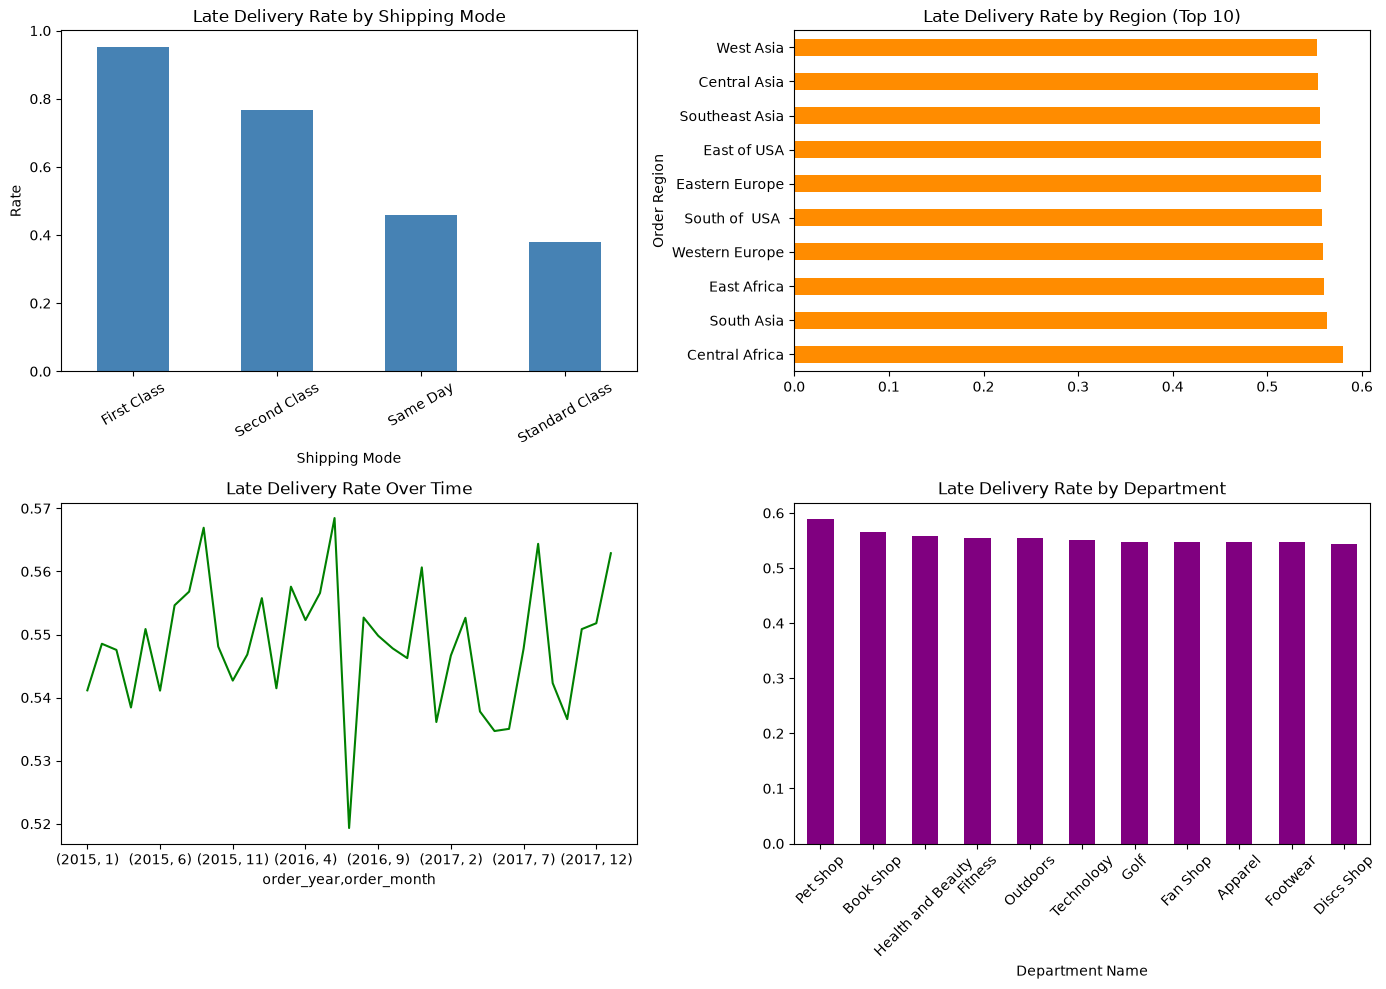

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Late delivery by Shipping Mode
sm_risk = df.groupby('Shipping Mode')['Late_delivery_risk'].mean().sort_values(ascending=False)
sm_risk.plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Late Delivery Rate by Shipping Mode')
axes[0,0].set_ylabel('Rate')
axes[0,0].tick_params(axis='x', rotation=30)

# Plot 2: Late delivery by Order Region
reg_risk = df.groupby('Order Region')['Late_delivery_risk'].mean().sort_values(ascending=False).head(10)
reg_risk.plot(kind='barh', ax=axes[0,1], color='darkorange')
axes[0,1].set_title('Late Delivery Rate by Region (Top 10)')

# Plot 3: Monthly trend
df['order_date'] = pd.to_datetime(df['order date (DateOrders)'], errors='coerce')
df['order_month'] = df['order_date'].dt.month
df['order_year']  = df['order_date'].dt.year
monthly = df.groupby(['order_year','order_month'])['Late_delivery_risk'].mean()
monthly.plot(ax=axes[1,0], color='green')
axes[1,0].set_title('Late Delivery Rate Over Time')

# Plot 4: Department breakdown
dept_risk = df.groupby('Department Name')['Late_delivery_risk'].mean().sort_values(ascending=False)
dept_risk.plot(kind='bar', ax=axes[1,1], color='purple')
axes[1,1].set_title('Late Delivery Rate by Department')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../data/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
